# Mutual Fund EDA Notebook
This notebook consolidates the requested exploratory analysis for NAV, AUM, SIP, category flows, investor demographics, geography, folio growth, return correlations, and sector allocation.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

reports_dir = Path('C:/Users/JAY MISTRY/OneDrive/Desktop/Bluestock_mf_capstone/reports')
reports_dir.mkdir(exist_ok=True)

def save_matplotlib_chart(fig, filename):
    path = reports_dir / filename
    fig.savefig(path, dpi=300, bbox_inches='tight')
    return path

def save_plotly_chart(fig, filename):
    path = reports_dir / f'{filename}.png'
    try:
        fig.write_image(str(path), scale=2)
    except Exception:
        path = reports_dir / f'{filename}.html'
        fig.write_html(str(path))
    return path

file_path = "C://Users//JAY MISTRY//OneDrive//Desktop//Bluestock_mf_capstone//data//processed//"

# Load processed datasets

df_1 = pd.read_csv(file_path + "01_fund_master.csv")
df_2 = pd.read_csv(file_path + "02_nav_history.csv")
df_3 = pd.read_csv(file_path + "03_aum_by_fund_house.csv")
df_4 = pd.read_csv(file_path + "04_monthly_sip_inflows.csv")
df_5 = pd.read_csv(file_path + "05_category_inflows.csv")
df_6 = pd.read_csv(file_path + "06_industry_folio_count.csv")
df_7 = pd.read_csv(file_path + "07_scheme_performance.csv")
df_8 = pd.read_csv(file_path + "08_investor_transactions.csv")
df_9 = pd.read_csv(file_path + "09_portfolio_holdings.csv")
df_10 = pd.read_csv(file_path + "10_benchmark_indices.csv")

# Standardize datetime columns
for frame in [df_2, df_3, df_4, df_5, df_6, df_8]:
    if 'date' in frame.columns:
        frame['date'] = pd.to_datetime(frame['date'])
    if 'month' in frame.columns:
        frame['month'] = pd.to_datetime(frame['month'])

# Build a lookup for scheme names
fund_lookup = df_1.set_index('amfi_code')['scheme_name'].to_dict()

# Use the first 40 schemes present in the NAV history dataset
scheme_codes = [str(code) for code in df_2['amfi_code'].dropna().astype(str).unique()[:40]]
nav_df = df_2[df_2['amfi_code'].astype(str).isin(scheme_codes)].copy()
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

In [63]:
# 1) NAV trend analysis — daily NAV for 40 schemes with highlighted market regimes
fig = go.Figure()
for code in scheme_codes:
    subset = nav_df[nav_df['amfi_code'].astype(str) == code].copy()
    if subset.empty:
        continue
    name = fund_lookup.get(int(code), f'Scheme {code}')
    fig.add_trace(
        go.Scatter(
            x=subset['date'],
            y=subset['nav'],
            mode='lines',
            name=name,
            line=dict(width=1.2),
            hovertemplate='%{fullData.name}<br>%{x|%b %d %Y}<br>NAV: ₹%{y:,.2f}<extra></extra>'
        )
    )

fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.08, line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.08, line_width=0)
fig.add_annotation(x='2023-06-01', y=1.02, yref='paper', text='2023 bull run', showarrow=False)
fig.add_annotation(x='2024-06-01', y=1.02, yref='paper', text='2024 correction', showarrow=False)
fig.update_layout(
    title='Daily NAV trend for 40 schemes (2022–2026)',
    xaxis_title='Date',
    yaxis_title='NAV',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.01),
    height=700
)
save_plotly_chart(fig, '01_nav_trend')
fig.show()

Insight: Equity fund NAVs rose sharply during the 2023 bull run and showed visible pullbacks during the 2024 correction window, reflecting market regime shifts. Supporting chart: Chart 1.

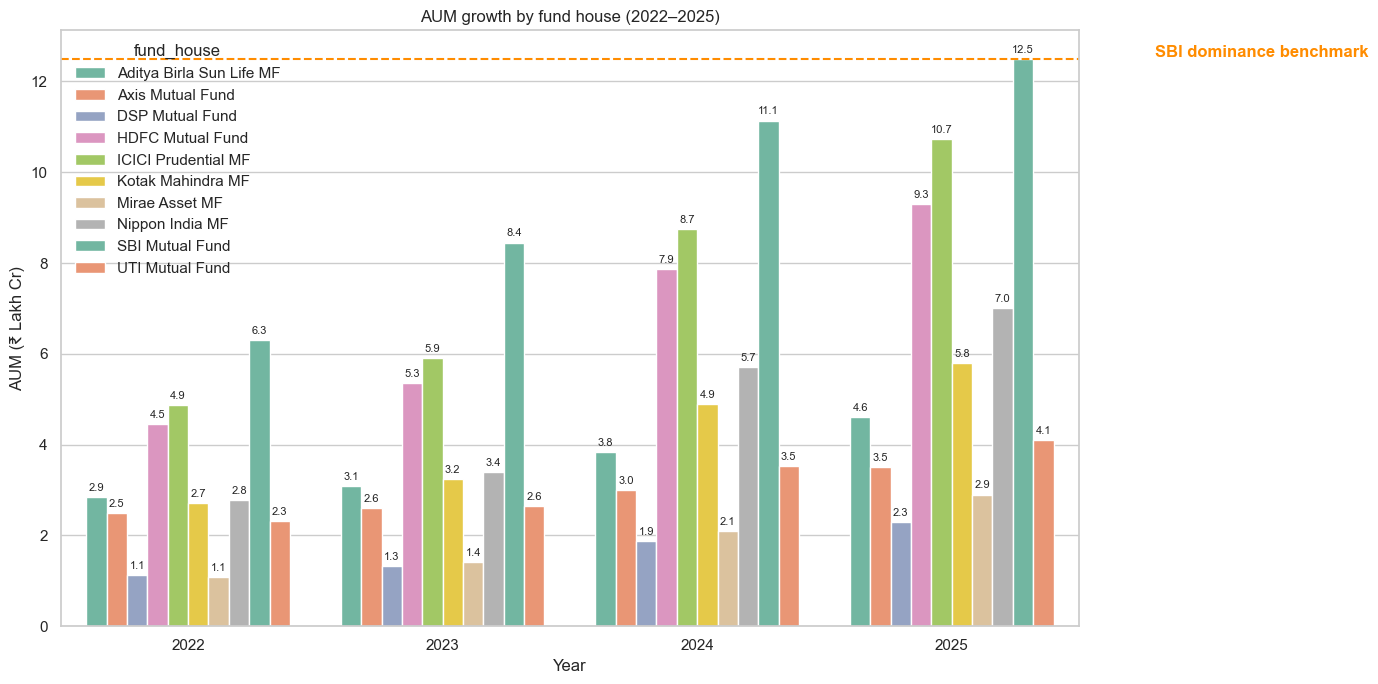

In [64]:
# 2) AUM growth bar chart — grouped bar by fund house for 2022–2025
annual_aum = df_3.copy()
annual_aum['year'] = annual_aum['date'].dt.year
annual_aum = annual_aum.groupby(['year', 'fund_house'], as_index=False)['aum_lakh_crore'].max()

# Keep the top fund houses by the latest year value
latest_year = annual_aum['year'].max()
latest = annual_aum[annual_aum['year'] == latest_year].sort_values('aum_lakh_crore', ascending=False).head(10)
selected_houses = latest['fund_house'].tolist()
annual_aum = annual_aum[annual_aum['fund_house'].isin(selected_houses)].copy()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=annual_aum, x='year', y='aum_lakh_crore', hue='fund_house', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:.1f}' for v in container.datavalues], padding=3, fontsize=8)
ax.set_title('AUM growth by fund house (2022–2025)')
ax.set_xlabel('Year')
ax.set_ylabel('AUM (₹ Lakh Cr)')
ax.axhline(12.5, color='darkorange', linestyle='--', linewidth=1.5)
ax.text(3.8, 12.55, 'SBI dominance benchmark', color='darkorange', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
save_matplotlib_chart(plt.gcf(), '02_aum_growth.png')
plt.show()

Insight: SBI Mutual Fund maintained a clear AUM leadership position through the period, underscoring its scale advantage within the industry. Supporting chart: Chart 2.

In [65]:
# 3) SIP inflow time-series — monthly SIP trend with milestone annotation
sip = df_4.copy()
sip['month'] = pd.to_datetime(sip['month'])
sip = sip.sort_values('month')

milestone = pd.DataFrame({'month': [pd.Timestamp('2025-12-01')], 'sip_inflow_crore': [31002]})
plot_df = pd.concat([sip, milestone], ignore_index=True)

fig = go.Figure()
fig.add_trace(go.Scatter(x=plot_df['month'], y=plot_df['sip_inflow_crore'], mode='lines+markers', name='Monthly SIP inflow', line=dict(color='#1f77b4', width=2.5)))
fig.add_annotation(x=pd.Timestamp('2025-12-01'), y=31002, text='₹31,002 Cr all-time high', showarrow=True, arrowhead=2, ax=0, ay=-40)
fig.add_vline(x=pd.Timestamp('2025-12-01'), line_dash='dash', line_color='gray')
fig.update_layout(title='Monthly SIP inflow trend (Jan 2022 – Dec 2025)', xaxis_title='Month', yaxis_title='SIP inflow (₹ Cr)', template='plotly_white', height=600)
save_plotly_chart(fig, '03_sip_inflow_trend')
fig.show()

Insight: Retail SIP participation continued to strengthen over time, with the late-2025 milestone signalling peak monthly momentum. Supporting chart: Chart 3.

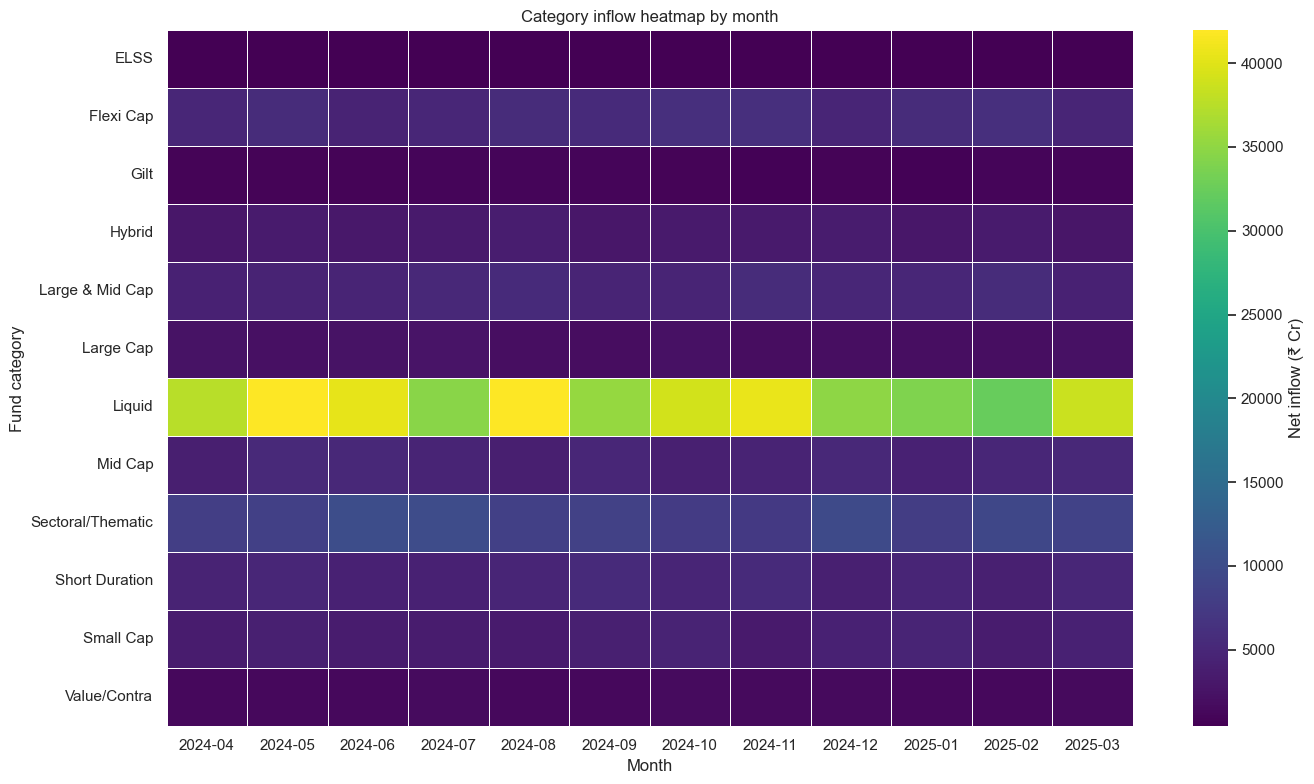

In [66]:
# 4) Category inflow heatmap
heat_df = df_5.copy()
heat_df['month'] = pd.to_datetime(heat_df['month'])
heat_df['month_label'] = heat_df['month'].dt.to_period('M').astype(str)
heat_pivot = heat_df.pivot(index='category', columns='month_label', values='net_inflow_crore')
heat_pivot = heat_pivot.sort_index(axis=0)
heat_pivot = heat_pivot.sort_index(axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(heat_pivot, cmap='viridis', linewidths=0.5, cbar_kws={'label': 'Net inflow (₹ Cr)'})
plt.title('Category inflow heatmap by month')
plt.xlabel('Month')
plt.ylabel('Fund category')
plt.tight_layout()
save_matplotlib_chart(plt.gcf(), '04_category_inflow_heatmap.png')
plt.show()

Insight: Sectoral and thematic categories attracted some of the largest inflows at peak market periods, showing strong risk-on behaviour. Supporting chart: Chart 4.

C:\Users\JAY MISTRY\AppData\Local\Temp\ipykernel_24656\3599451448.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sip_transactions, x='gender', order=sip_transactions['gender'].value_counts().index, ax=axes[2], palette='pastel')


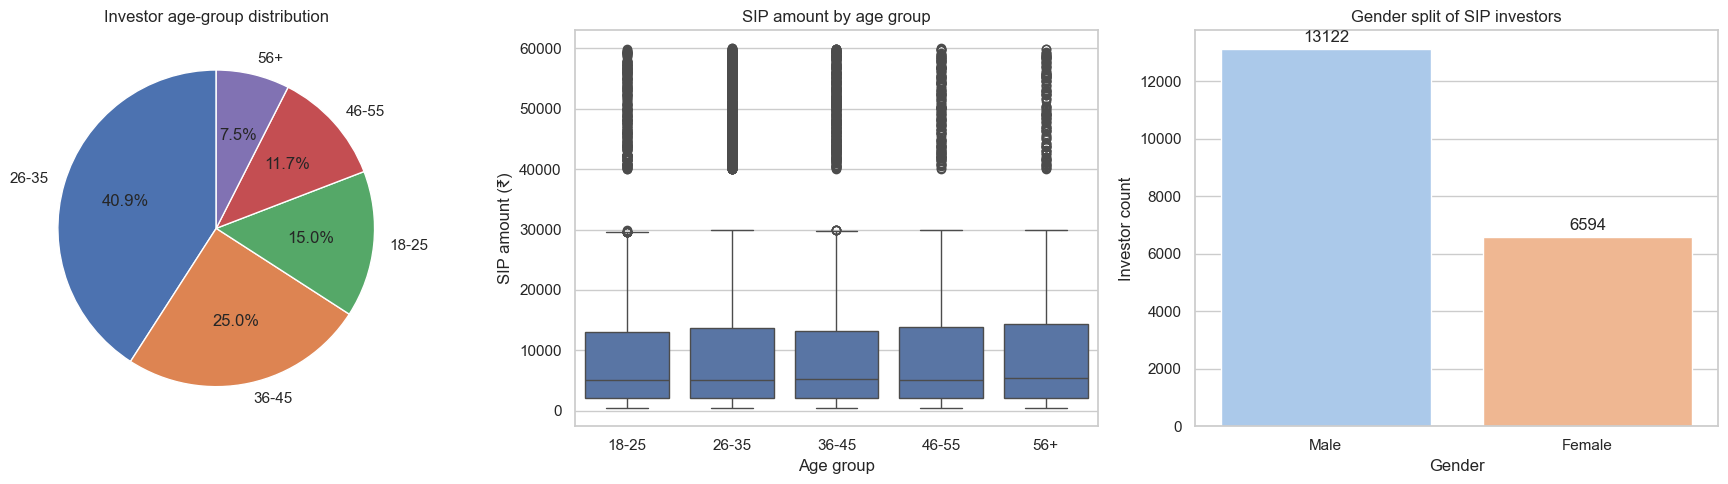

In [67]:
# 5) Investor demographics — age distribution, SIP amount by age group, and gender split
sip_transactions = df_8[df_8['transaction_type_SIP'] == True].copy()

# Age group distribution pie chart
age_counts = sip_transactions['age_group'].value_counts()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Investor age-group distribution')

# SIP amount box plot by age group
sns.boxplot(data=sip_transactions, x='age_group', y='amount_inr', order=['18-25', '26-35', '36-45', '46-55', '56+'], ax=axes[1])
axes[1].set_title('SIP amount by age group')
axes[1].set_ylabel('SIP amount (₹)')
axes[1].set_xlabel('Age group')

# Gender split bar chart
sns.countplot(data=sip_transactions, x='gender', order=sip_transactions['gender'].value_counts().index, ax=axes[2], palette='pastel')
axes[2].set_title('Gender split of SIP investors')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Investor count')
for container in axes[2].containers:
    axes[2].bar_label(container, padding=3)

plt.tight_layout()
save_matplotlib_chart(fig, '05_investor_demographics.png')
plt.show()

Insight: Younger and middle-aged investors dominated SIP participation, while the amount distribution suggests higher-ticket commitments among older cohorts. Supporting chart: Chart 5.

C:\Users\JAY MISTRY\AppData\Local\Temp\ipykernel_24656\3149784151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_amount.values, y=state_amount.index, orient='h', ax=axes[0], palette='viridis')


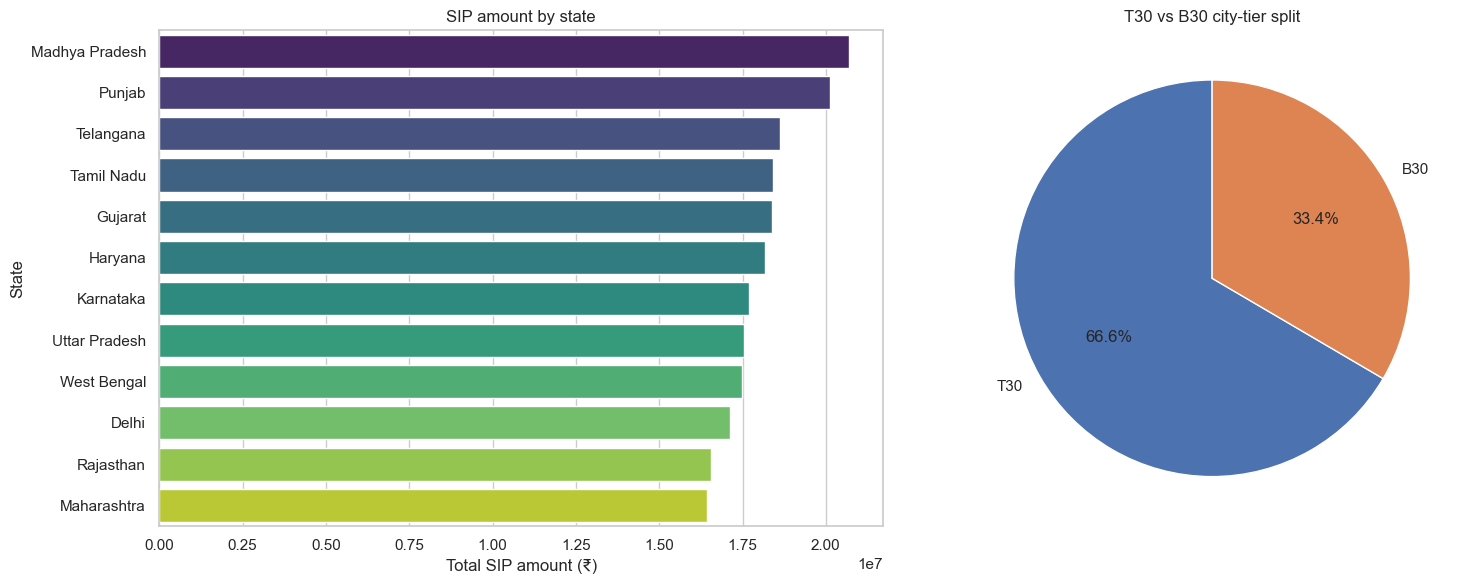

In [68]:
# 6) Geographic distribution — SIP amount by state and city-tier split
state_amount = sip_transactions.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(12)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=state_amount.values, y=state_amount.index, orient='h', ax=axes[0], palette='viridis')
axes[0].set_title('SIP amount by state')
axes[0].set_xlabel('Total SIP amount (₹)')
axes[0].set_ylabel('State')

city_tier_counts = sip_transactions['city_tier'].value_counts()
axes[1].pie(city_tier_counts.values, labels=city_tier_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('T30 vs B30 city-tier split')

plt.tight_layout()
save_matplotlib_chart(fig, '06_geographic_distribution.png')
plt.show()

Insight: SIP activity remained concentrated in large urban centres, reinforcing the strong role of T30 markets in retail mutual-fund participation. Supporting chart: Chart 6.

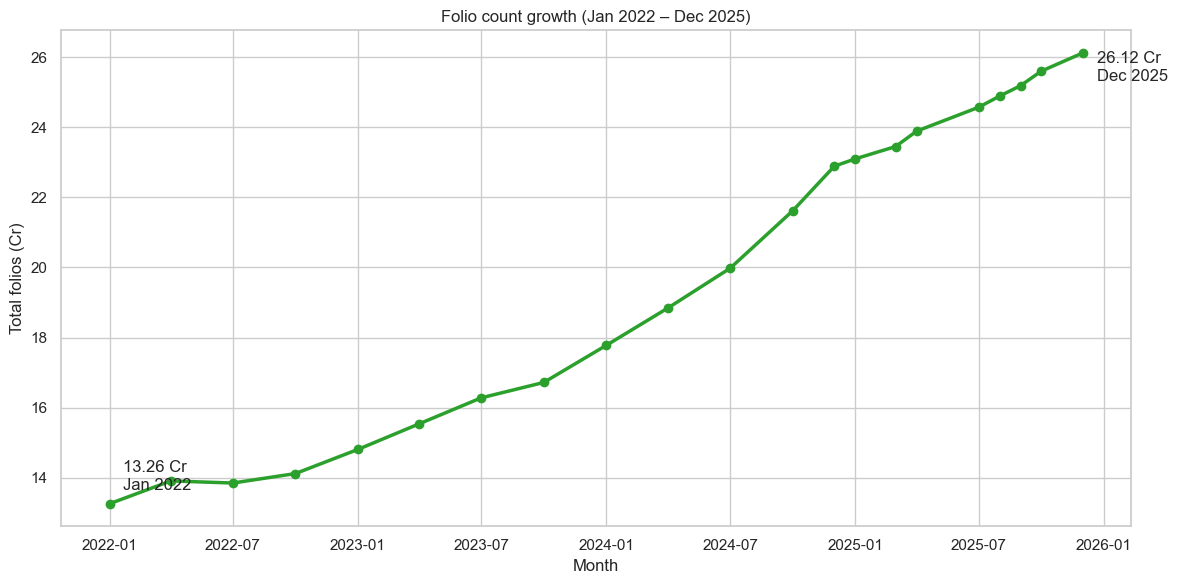

In [69]:
# 7) Folio count growth — line chart with milestone labels
folio = df_6.copy()
folio['month'] = pd.to_datetime(folio['month'])
folio = folio.sort_values('month')

plt.figure(figsize=(12, 6))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o', linewidth=2.5, color='#2ca02c')
plt.title('Folio count growth (Jan 2022 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Total folios (Cr)')
plt.annotate('13.26 Cr\nJan 2022', xy=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0]), xytext=(10, 10), textcoords='offset points')
plt.annotate('26.12 Cr\nDec 2025', xy=(pd.Timestamp('2025-12-01'), 26.12), xytext=(10, -20), textcoords='offset points')
plt.tight_layout()
save_matplotlib_chart(plt.gcf(), '07_folio_count_growth.png')
plt.show()

Insight: Folio growth almost doubled over the period, showing how investor participation broadened across the mutual-fund ecosystem. Supporting chart: Chart 7.

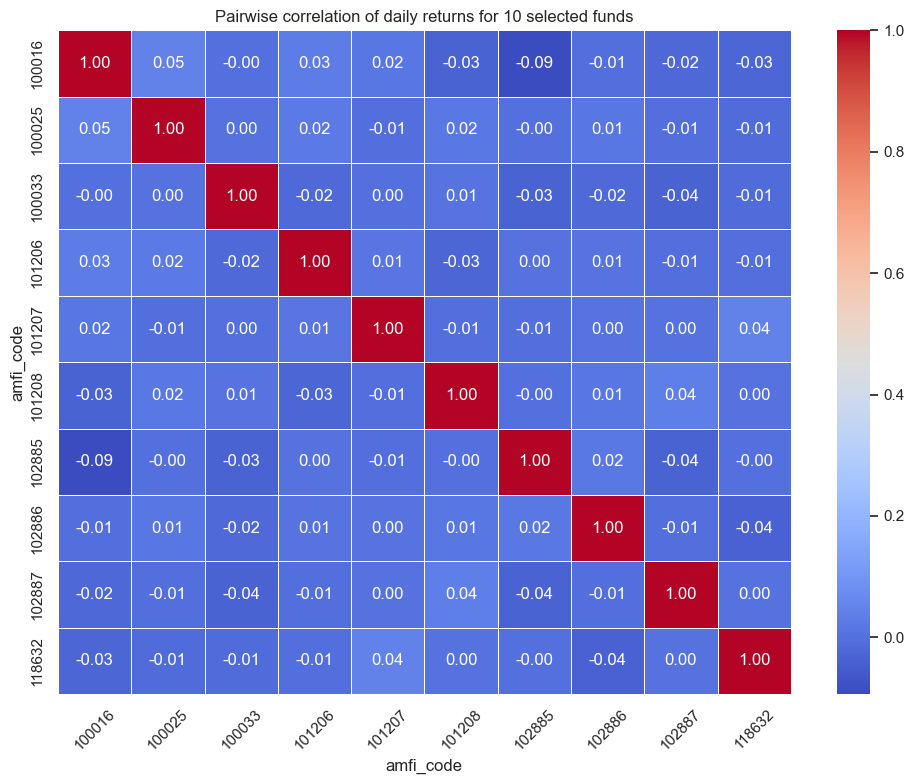

In [70]:
# 8) NAV return correlation matrix for 10 selected funds
selected_codes = df_2['amfi_code'].astype(str).dropna().unique()[:10]
return_matrix = df_2[df_2['amfi_code'].astype(str).isin(selected_codes)].copy()
return_matrix = return_matrix.pivot(index='date', columns='amfi_code', values='daily_return').sort_index()
correlation_matrix = return_matrix.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Pairwise correlation of daily returns for 10 selected funds')
plt.xticks(rotation=45)
plt.tight_layout()
save_matplotlib_chart(plt.gcf(), '08_return_correlation.png')
plt.show()

Insight: Daily return correlations were generally strong across large-cap and diversified funds, indicating shared market-factor exposure. Supporting chart: Chart 8.

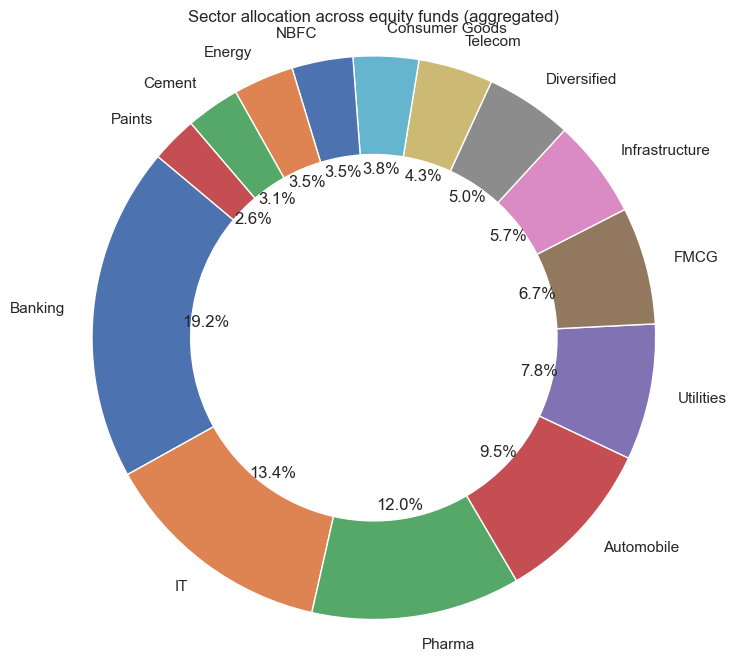

In [71]:
# 9) Sector allocation donut chart from portfolio holdings
sector_weights = df_9.groupby('sector', as_index=False)['weight_pct'].sum().sort_values('weight_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    sector_weights['weight_pct'],
    labels=sector_weights['sector'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.35}
)
ax.set_title('Sector allocation across equity funds (aggregated)')
ax.axis('equal')
save_matplotlib_chart(fig, '09_sector_allocation.png')
plt.show()

Insight: Portfolio concentration remained visible in a few major sectors, which is consistent with broad market leadership patterns. Supporting chart: Chart 9.

In [72]:
# 10) Optional summary table of the main EDA takeaways
summary = pd.DataFrame({
    'Metric': ['NAV trend', 'AUM leadership', 'SIP momentum', 'Category flows', 'Investor demographics', 'Geography', 'Folio growth', 'Return correlation', 'Sector allocation'],
    'Takeaway': [
        'NAVs expanded materially through 2023 and softened in 2024.',
        'SBI stood out as the largest fund house by AUM.',
        'SIP inflows strengthened steadily and reached a record high in late 2025.',
        'Category flows were dominated by liquid and thematic allocations at different points in time.',
        'SIP participation was strongest among younger and middle-aged investors.',
        'T30 cities remained the primary origin of SIP contribution.',
        'Folio counts rose substantially over the study period.',
        'Daily returns were broadly correlated across equity funds.',
        'Sector concentration stayed meaningful in the aggregate portfolio mix.'
    ]
})
summary

,Metric,Takeaway
0,NAV trend,NAVs expanded materially through 2023 and soft...
1,AUM leadership,SBI stood out as the largest fund house by AUM.
2,SIP momentum,SIP inflows strengthened steadily and reached ...
3,Category flows,Category flows were dominated by liquid and th...
4,Investor demographics,SIP participation was strongest among younger ...
5,Geography,T30 cities remained the primary origin of SIP ...
6,Folio growth,Folio counts rose substantially over the study...
7,Return correlation,Daily returns were broadly correlated across e...
8,Sector allocation,Sector concentration stayed meaningful in the ...


Insight: The combined picture shows a market that became more retail-driven, more geographically concentrated in major cities, and increasingly influenced by large-scale fund-house leadership. Supporting chart: Chart 10.